# Reward Component Plot


In [1]:
APPROACH = 'happo'
MODLABEL = 'uav4_ugv3_area_1sqkm_malibu_grid256_steps900_fire_survivors_5_to_10_dropout0p0'
CKPT = "results/harl_runs/wildfire/wildfire_search/happo/happo_uav4_ugv3_area_1sqkm_malibu_grid256_steps900_fire_survivors_10/seed-00001-2026-07-19-00-15-35/models"
NSTEPS_PER_EPISODE = 900
SEED_START = 1000
SEED_END = 1099

NSURVIVORS_OBS = 10
NSURVIVORS_MIN = 5
NSURVIVORS_MAX = 10

FILENAME = 'outputs/baseline_comparison/happo_uav4_ugv3_area_1sqkm_malibu_grid256_steps900_fire_survivors_5_to_10_dropout0p0_seeds_1000_1099.json'
OUTPUT_PNG = 'outputs/figures/uav_reward_scale_replot.png'
TB_RUN_DIR = 'results/harl_runs/wildfire/wildfire_search/happo/happo_uav4_ugv3_area_1sqkm_malibu_grid256_steps900_fire_survivors_10/seed-00001-2026-07-19-00-15-35'
TB_LOG_DIR = f'{TB_RUN_DIR}/logs'
AVER_REWARD_TB_DIR = f'{TB_LOG_DIR}/train_episode_rewards/aver_rewards'
AVER_REWARD_TB_TAG = 'train_episode_rewards'
AVER_REWARD_OUTPUT_PNG = 'outputs/figures/average_reward_replot.png'
AGENT_REWARD_TB_DIR = f'{TB_LOG_DIR}/train_episode_rewards_by_agent'
AGENT_REWARD_TB_TAG = 'train_episode_rewards_by_agent'
AGENT_REWARD_OUTPUT_PNG = 'outputs/figures/agent_reward_replot.png'
CRITIC_VALUE_LOSS_TB_DIR = f'{TB_LOG_DIR}/critic/value_loss/critic/value_loss'
CRITIC_VALUE_LOSS_TB_TAG = 'critic/value_loss'
CRITIC_GRAD_NORM_TB_DIR = f'{TB_LOG_DIR}/critic/critic_grad_norm/critic/critic_grad_norm'
CRITIC_GRAD_NORM_TB_TAG = 'critic/critic_grad_norm'
CRITIC_OUTPUT_PNG = 'outputs/figures/critic_training_replot.png'

In [2]:
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator


PAPER_BG = '#f2ebd3ff'
PAPER_BG = 'white'
GRID_COLOR = '#cfc7ad'
TEXT_GREEN = '#23562f'
TEXT_GREEN = '#002676'
TEXT_DARK = '#2f2a24'
SPINE_COLOR = '#9d9279'

UAV_REWARD_COMPONENTS = [
    ('team', 'Team reward', '#8f2418', 'o'),
    ('team_scout', 'Team scout reward', '#c94a27', 's'),
    ('drone_scout', 'Drone scout reward', '#e09b4f', 'o'),
    ('uav_inefficient', 'Inefficient move penalty', '#7b7160', 'D'),
    ('uav_conf', 'Confidence gain reward', '#1f5a35', 'o'),
    ('uav_conf_move', 'Confidence-weighted movement reward', '#5f812f', 's'),
    ('uav_conf_overlap', 'Confidence-overlap penalty', '#9ba04d', '^'),
    ('uav_frontier', 'Frontier', '#2f7560', 'v'),
    ('uav_outside', 'Outside penalty', '#6f6758', 'P'),
    ('uav_fire', 'Fire penalty', '#d44a3a', 'X'),
]

plt.rcParams.update({
    'figure.facecolor': PAPER_BG,
    'axes.facecolor': PAPER_BG,
    'axes.edgecolor': SPINE_COLOR,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titleweight': 'bold',
    'axes.titlesize': 18,
    'axes.labelsize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'text.color': TEXT_DARK,
    'axes.labelcolor': TEXT_DARK,
    'xtick.color': TEXT_DARK,
    'ytick.color': TEXT_DARK,
    'legend.frameon': True,
    'font.family': 'serif',
})


def resolve_project_path(path):
    path = Path(path).expanduser()
    if path.is_absolute():
        return path
    cwd = Path.cwd().resolve()
    candidates = [
        cwd / path,
        cwd / 'notebooks' / path,
        cwd.parent / path,
        cwd.parent / 'notebooks' / path,
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    
    candidate = cwd.parent / path
    return candidate.resolve()


def style_axis(ax):
    ax.grid(axis='y', color=GRID_COLOR, alpha=0.55, linewidth=0.9)
    ax.grid(axis='x', color=GRID_COLOR, alpha=0.30, linewidth=0.9)
    ax.spines['left'].set_color(SPINE_COLOR)
    ax.spines['bottom'].set_color(SPINE_COLOR)
    ax.tick_params(colors=TEXT_DARK)
    ax.set_axisbelow(True)


def resolve_notebook_path(path):
    path = Path(path).expanduser()
    if path.is_absolute():
        return path
    cwd = Path.cwd().resolve()
    if cwd.name == 'notebooks':
        candidates = [cwd / path, cwd.parent / 'notebooks' / path, cwd.parent / path]
    else:
        candidates = [cwd / 'notebooks' / path, cwd / path, cwd.parent / 'notebooks' / path]
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    return candidates[0].resolve()


def load_tb_scalar(log_dir, tag):
    log_dir = resolve_project_path(log_dir)
    if not log_dir.is_dir():
        raise FileNotFoundError(f'TensorBoard log directory not found: {log_dir}')
    accumulator = EventAccumulator(str(log_dir), size_guidance={'scalars': 0})
    accumulator.Reload()
    scalar_tags = accumulator.Tags().get('scalars', [])
    if tag not in scalar_tags:
        raise ValueError(f'Tag {tag!r} not found in {log_dir}. Available tags: {scalar_tags}')
    scalars = accumulator.Scalars(tag)
    return pd.DataFrame({
        'wall_time': [item.wall_time for item in scalars],
        'step': [item.step for item in scalars],
        'reward': [item.value for item in scalars],
    })

In [3]:
json_path = resolve_project_path(FILENAME)

with json_path.open() as f:
    payload = json.load(f)

rows = payload.get('rows', [])
records = []
for row in rows:
    seed = row.get('seed')
    for bin_index, bin_row in enumerate(row.get('time_bins', [])):
        episode_fraction = bin_row.get('episode_fraction')
        for component, label, color, marker in UAV_REWARD_COMPONENTS:
            key = f'uav_reward_{component}'
            value = bin_row.get(key)
            if value is None:
                continue
            records.append({
                'seed': seed,
                'bin_index': bin_index,
                'episode_fraction': episode_fraction,
                'component': component,
                'label': label,
                'value': float(value),
            })

reward_long = pd.DataFrame.from_records(records)
if reward_long.empty:
    raise ValueError(f'No UAV reward time-bin values found in {json_path}')

reward_summary = (
    reward_long
    .groupby(['component', 'label', 'bin_index', 'episode_fraction'], as_index=False)
    .agg(mean=('value', 'mean'), std=('value', 'std'), count=('value', 'count'))
    .sort_values(['component', 'episode_fraction'])
)
reward_summary.head()

,component,label,bin_index,episode_fraction,mean,std,count
0,drone_scout,Drone scout reward,0,0.1,0.058000,0.020986,100
1,drone_scout,Drone scout reward,1,0.3,0.018667,0.013757,100
2,drone_scout,Drone scout reward,2,0.5,0.003889,0.006391,100
3,drone_scout,Drone scout reward,3,0.7,0.000444,0.002699,100
4,drone_scout,Drone scout reward,4,0.9,0.000556,0.002434,100


Saved /Users/aschuetz/Software/capstone/omnisearch/outputs/figures/uav_reward_scale_replot.png


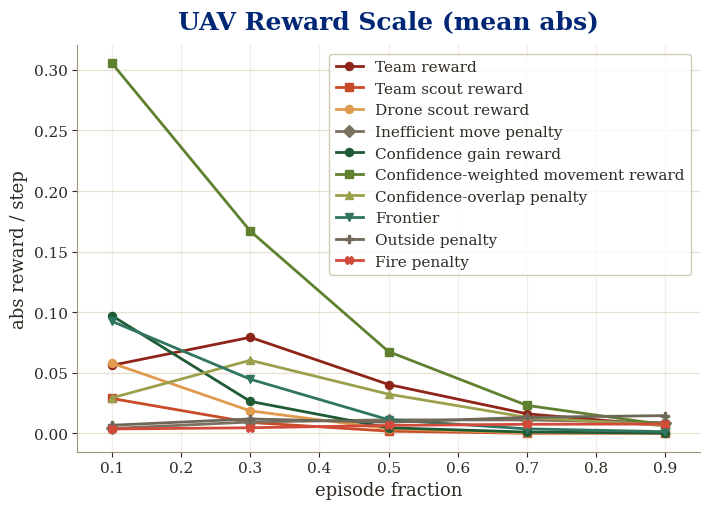

In [4]:
fig, ax = plt.subplots(figsize=(7.2, 5.2), facecolor=PAPER_BG)
ax.set_facecolor(PAPER_BG)

plotted = []
for component, label, color, marker in UAV_REWARD_COMPONENTS:
    series = reward_summary[reward_summary['component'] == component].sort_values('episode_fraction')
    if series.empty or not (series['mean'] > 1e-10).any():
        continue
    ax.plot(
        series['episode_fraction'],
        series['mean'],
        marker=marker,
        markersize=5.8,
        linewidth=2.0,
        color=color,
        label=label,
    )
    plotted.append(label)

ax.set_title('UAV Reward Scale (mean abs)', color=TEXT_GREEN, pad=12)
ax.set_xlabel('episode fraction')
ax.set_ylabel('abs reward / step')
ax.set_xlim(0.05, 0.95)
style_axis(ax)

legend = ax.legend(
    loc='upper right',
    ncol=1,
    fontsize=11,
    borderaxespad=0.6,
    handlelength=1.8,
    columnspacing=1.1,
)
legend.get_frame().set_facecolor(PAPER_BG)
legend.get_frame().set_edgecolor('#c8bea4')

fig.tight_layout()
output_path = resolve_project_path(OUTPUT_PNG)
output_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(output_path, dpi=220, bbox_inches='tight', facecolor=PAPER_BG)
print(f'Saved {output_path}')

Saved /Users/aschuetz/Software/capstone/omnisearch/outputs/figures/average_reward_replot.png


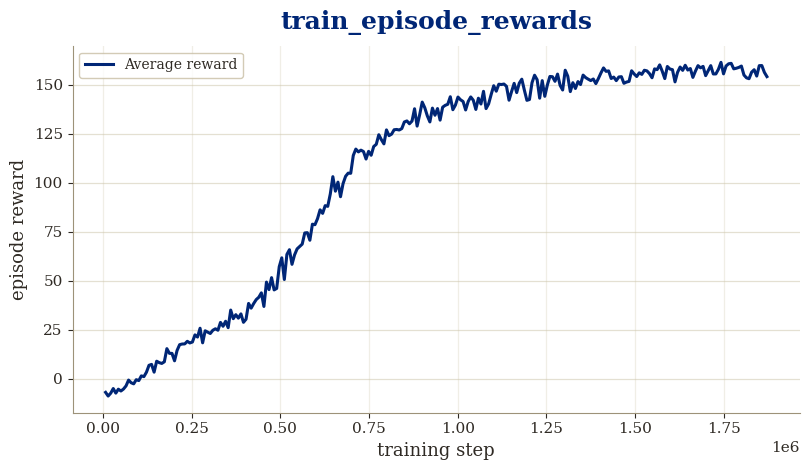

In [5]:
def _first_existing_column(df, candidates):
    normalized = {str(col).lower().replace(' ', '_'): col for col in df.columns}
    for candidate in candidates:
        key = candidate.lower().replace(' ', '_')
        if key in normalized:
            return normalized[key]
    return None


def _records_to_reward_frame(records):
    df = pd.DataFrame.from_records(records)
    if df.empty:
        return df

    x_col = _first_existing_column(
        df,
        ['step', 'steps', 'timestep', 'timesteps', 'global_step', 'update', 'iteration', 'epoch', 'episode'],
    )
    y_col = _first_existing_column(
        df,
        ['average_reward', 'aver_reward', 'avg_reward', 'mean_reward', 'episode_reward', 'reward', 'value'],
    )
    if y_col is None:
        reward_like = [col for col in df.columns if 'reward' in str(col).lower()]
        y_col = reward_like[0] if reward_like else None
    if y_col is None:
        numeric_cols = [col for col in df.columns if pd.to_numeric(df[col], errors='coerce').notna().any()]
        y_col = numeric_cols[-1] if numeric_cols else None
    if y_col is None:
        return pd.DataFrame()

    out = pd.DataFrame({'reward': pd.to_numeric(df[y_col], errors='coerce')})
    if x_col is None:
        out['step'] = np.arange(len(out), dtype=float)
    else:
        out['step'] = pd.to_numeric(df[x_col], errors='coerce')
    return out.dropna(subset=['step', 'reward']).sort_values('step')


def _average_reward_frame(data):
    if isinstance(data, list):
        if not data:
            return pd.DataFrame()
        if isinstance(data[0], dict):
            return _records_to_reward_frame(data)
        if isinstance(data[0], (list, tuple)) and len(data[0]) >= 3:
            return pd.DataFrame({
                'wall_time': [row[0] for row in data],
                'step': [row[1] for row in data],
                'reward': [row[2] for row in data],
            }).apply(pd.to_numeric, errors='coerce').dropna(subset=['step', 'reward'])
        if isinstance(data[0], (list, tuple)) and len(data[0]) >= 2:
            return pd.DataFrame({
                'step': [row[0] for row in data],
                'reward': [row[1] for row in data],
            }).apply(pd.to_numeric, errors='coerce').dropna()
        return pd.DataFrame({'step': np.arange(len(data), dtype=float), 'reward': data}).apply(pd.to_numeric, errors='coerce').dropna()

    if isinstance(data, dict):
        for nested_key in ['data', 'rows', 'scalars', 'values', 'average_reward', 'aver_reward']:
            nested = data.get(nested_key)
            if isinstance(nested, (list, dict)):
                parsed = _average_reward_frame(nested)
                if not parsed.empty:
                    return parsed

        array_lengths = {key: len(value) for key, value in data.items() if isinstance(value, list)}
        if array_lengths:
            df = pd.DataFrame({key: data[key] for key in array_lengths})
            return _records_to_reward_frame(df.to_dict('records'))

    return pd.DataFrame()


average_reward = load_tb_scalar(AVER_REWARD_TB_DIR, AVER_REWARD_TB_TAG)
if average_reward.empty:
    raise ValueError(f'No TensorBoard scalar values found for {AVER_REWARD_TB_TAG}')

fig, ax = plt.subplots(figsize=(8.2, 4.8), facecolor=PAPER_BG)
ax.set_facecolor(PAPER_BG)
ax.plot(
    average_reward['step'],
    average_reward['reward'],
    color=TEXT_GREEN,
    marker='o' if len(average_reward) <= 80 else None,
    markersize=4.0,
    linewidth=2.2,
    label='Average reward',
)
ax.set_title('train_episode_rewards', color=TEXT_GREEN, pad=12)
ax.set_xlabel('training step')
ax.set_ylabel('episode reward')
style_axis(ax)
legend = ax.legend(loc='best', fontsize=10)
legend.get_frame().set_facecolor(PAPER_BG)
legend.get_frame().set_edgecolor('#c8bea4')

fig.tight_layout()
average_reward_output_path = resolve_project_path(AVER_REWARD_OUTPUT_PNG)
average_reward_output_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(average_reward_output_path, dpi=220, bbox_inches='tight', facecolor=PAPER_BG)
print(f'Saved {average_reward_output_path}')

Saved /Users/aschuetz/Software/capstone/omnisearch/outputs/figures/agent_reward_replot.png


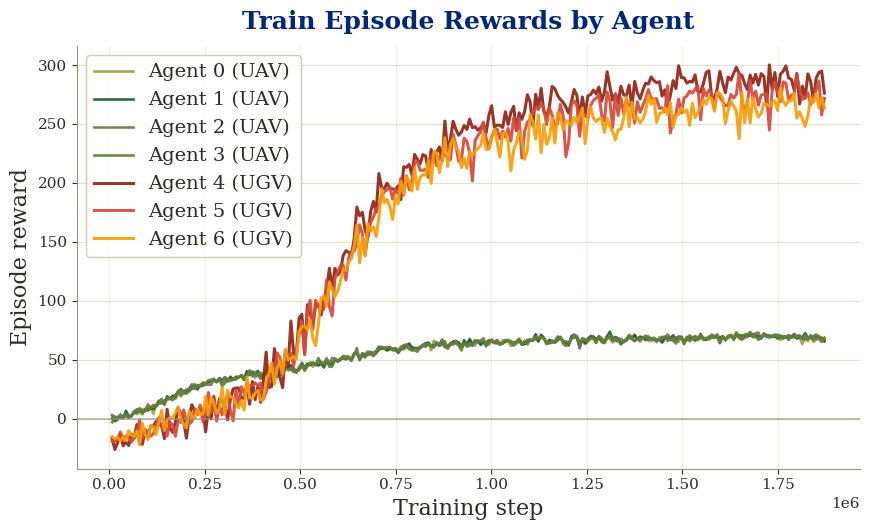

In [6]:
def _agent_sort_key(path):
    match = re.search(r'agent(\d+)', path.stem)
    return int(match.group(1)) if match else path.stem


def _agent_label(path):
    match = re.match(r'agent(\d+)_(uav|ugv)$', path.stem, flags=re.IGNORECASE)
    if match:
        return f'Agent {int(match.group(1))} ({match.group(2).upper()})'
    return path.stem.replace('_', ' ').title()


def resolve_glob(pattern):
    pattern = Path(pattern).expanduser()
    if pattern.is_absolute():
        return sorted(pattern.parent.glob(pattern.name), key=_agent_sort_key), pattern
    cwd = Path.cwd().resolve()
    candidates = [
        cwd / pattern,
        cwd.parent / pattern,
        cwd / 'notebooks' / pattern,
        cwd.parent / 'notebooks' / pattern,
    ]
    for candidate in candidates:
        matches = sorted(candidate.parent.glob(candidate.name), key=_agent_sort_key)
        if matches:
            return matches, candidate
    return [], candidates[0]


agent_root = resolve_project_path(AGENT_REWARD_TB_DIR)
agent_dirs = sorted([path for path in agent_root.glob('agent*_*') if path.is_dir()], key=_agent_sort_key)
if not agent_dirs:
    print(f'No agent TensorBoard log directories found in: {agent_root}')
else:
    agent_palette = {
        'agent0_uav':  '#9ba04d',
        'agent1_uav':  '#1f5a35',
        'agent2_uav':  '#7b7160',
        'agent3_uav': '#5f812f',
        'agent4_ugv': '#8f2418',
        'agent5_ugv': '#d44a3a',
        'agent6_ugv': '#f59e0b',
    }


    fig, ax = plt.subplots(figsize=(8.8, 5.4), facecolor=PAPER_BG)
    ax.set_facecolor(PAPER_BG)
    agent_rewards = {}
    for path in agent_dirs:
        series = load_tb_scalar(path, AGENT_REWARD_TB_TAG)
        if series.empty:
            print(f'Skipping {path.name}: no TensorBoard scalar values found')
            continue

        key = path.stem
        label = _agent_label(path)
        agent_rewards[label] = series
        agent_type = key.rsplit('_', 1)[-1]
        ax.plot(
            series['step'],
            series['reward'],
            color=agent_palette.get(key),
            linewidth=1.9 if agent_type == 'uav' else 2.2,
            alpha=0.92,
            label=label,
        )

    if not agent_rewards:
        raise ValueError(f'No plottable agent reward series found in {agent_root}')

    ax.axhline(0.0, color=SPINE_COLOR, linewidth=1.1, alpha=0.75)
    ax.set_title('Train Episode Rewards by Agent', color=TEXT_GREEN, pad=12)
    ax.set_xlabel('Training step', fontsize=16)
    ax.set_ylabel('Episode reward', fontsize=16)
    style_axis(ax)
    legend = ax.legend(loc='upper left', ncol=1, fontsize=14)
    legend.get_frame().set_facecolor(PAPER_BG)
    legend.get_frame().set_edgecolor('#c8bea4')

    fig.tight_layout()
    agent_reward_output_path = resolve_project_path(AGENT_REWARD_OUTPUT_PNG)
    agent_reward_output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(agent_reward_output_path, dpi=220, bbox_inches='tight', facecolor=PAPER_BG)
    print(f'Saved {agent_reward_output_path}')

Saved /Users/aschuetz/Software/capstone/omnisearch/outputs/figures/critic_training_replot.png


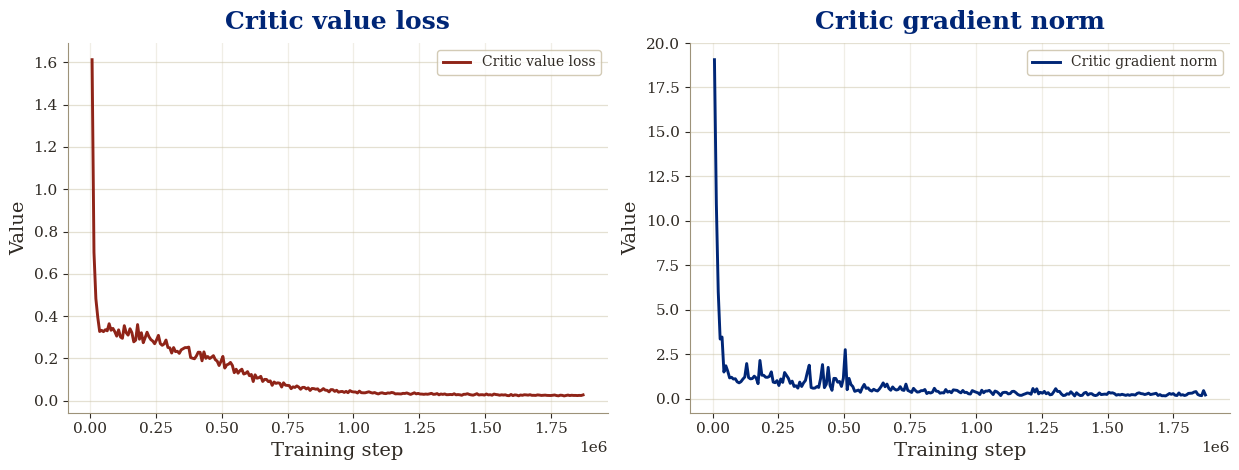

In [7]:
critic_specs = [
    (CRITIC_VALUE_LOSS_TB_DIR, CRITIC_VALUE_LOSS_TB_TAG, 'Critic value loss', '#8f2418'),
    (CRITIC_GRAD_NORM_TB_DIR, CRITIC_GRAD_NORM_TB_TAG, 'Critic gradient norm', TEXT_GREEN),
]

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8), facecolor=PAPER_BG)
critic_series = {}
for ax, (log_dir, tag, title, color) in zip(axes, critic_specs):
    series = load_tb_scalar(log_dir, tag)
    if series.empty:
        raise ValueError(f'No TensorBoard scalar values found for {tag}')

    critic_series[title] = series
    ax.set_facecolor(PAPER_BG)
    ax.plot(
        series['step'],
        series['reward'],
        color=color,
        linewidth=2.1,
        label=title,
    )
    ax.set_title(title, color=TEXT_GREEN, pad=10)
    ax.set_xlabel('Training step', fontsize=14)
    ax.set_ylabel('Value', fontsize=14)
    style_axis(ax)
    legend = ax.legend(loc='best', fontsize=10)
    legend.get_frame().set_facecolor(PAPER_BG)
    legend.get_frame().set_edgecolor('#c8bea4')

fig.tight_layout()
critic_output_path = resolve_project_path(CRITIC_OUTPUT_PNG)
critic_output_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(critic_output_path, dpi=220, bbox_inches='tight', facecolor=PAPER_BG)
print(f'Saved {critic_output_path}')